## Resultados Generador Agrawal

In [1]:
from src.data.agrawal_drift_generator import main
main()

/home/edubv/Concept_drift/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generated 20000 samples in 40 blocks at: datasets/agrawal_abrupt.csv
Dataset generado: datasets/agrawal_abrupt.csv (20000 filas, 40 bloques)
Dataset generado: datasets/agrawal_gradual.csv (20000 filas, 40 bloques)
Generated 20000 samples in 40 blocks at: datasets/agrawal_recurrent.csv
Dataset generado: datasets/agrawal_recurrent.csv (20000 filas, 40 bloques)
Generación completada y validada para abrupt, gradual y recurrent.


In [2]:
from src.run_passive_ensembles import run_experiment

res_recurrent = run_experiment("datasets/agrawal_recurrent.csv")
res_abrupt = run_experiment("datasets/agrawal_abrupt.csv")
res_gradual = run_experiment("datasets/agrawal_gradual.csv")


=== Results for agrawal_recurrent ===

SEA
  Runs               : 1
  Accuracy mean      : 0.7061 ± 0.0000
  Accuracy min       : 0.4740 ± 0.0000
  Recovery mean      : 8.5
  Kappa mean         : 0.3951 ± 0.0000
  Diversity mean     : 0.2384 ± 0.0000
  Time mean (s)      : 15.6395 ± 0.0000
  Num drops          : 2 ± 0.00

AUE2
  Runs               : 1
  Accuracy mean      : 0.7161 ± 0.0000
  Accuracy min       : 0.4740 ± 0.0000
  Recovery mean      : 8.5
  Kappa mean         : 0.4084 ± 0.0000
  Diversity mean     : 0.2387 ± 0.0000
  Time mean (s)      : 19.6622 ± 0.0000
  Num drops          : 2 ± 0.00

WAE
  Runs               : 1
  Accuracy mean      : 0.7215 ± 0.0000
  Accuracy min       : 0.4700 ± 0.0000
  Recovery mean      : 9.0
  Kappa mean         : 0.4157 ± 0.0000
  Diversity mean     : 0.2430 ± 0.0000
  Time mean (s)      : 21.2338 ± 0.0000
  Num drops          : 2 ± 0.00

Learn++NSE
  Runs               : 1
  Accuracy mean      : 0.7390 ± 0.0000
  Accuracy min       : 0.4720

In [3]:
import pandas as pd

def results_to_df(results_dict):
    rows = []

    for model, m in results_dict.items():
        rows.append({
            "Model": model,
            "Accuracy": m["accuracy_mean_mean"],
            "Min Accuracy": m["accuracy_min_mean"],
            "Kappa": m["kappa_mean_mean"],
            "Diversity": m["diversity_mean_mean"],
            "Time (s)": m["time_mean"],
            "Recovery": m["recovery_mean_mean"],
            "Num Drops": m["num_drops_mean"],
        })

    df = pd.DataFrame(rows)
    return df.sort_values(by="Accuracy", ascending=False).round(4)

In [4]:
df_recurrent = results_to_df(res_recurrent)
df_abrupt    = results_to_df(res_abrupt)
df_gradual   = results_to_df(res_gradual)

In [5]:
print("=== Gradual Drift ===")
df_gradual.style.background_gradient(cmap="Oranges")

=== Gradual Drift ===


/home/edubv/Concept_drift/.venv/lib/python3.10/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/edubv/Concept_drift/.venv/lib/python3.10/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.721300,0.534000,0.576000,0.176700,11.498600,nan,0.000000
2,WAE,0.708900,0.530000,0.553500,0.181900,19.714200,nan,0.000000
1,AUE2,0.704100,0.504000,0.563700,0.179000,18.451900,nan,0.000000
0,SEA,0.702000,0.502000,0.561800,0.175400,14.399700,nan,0.000000


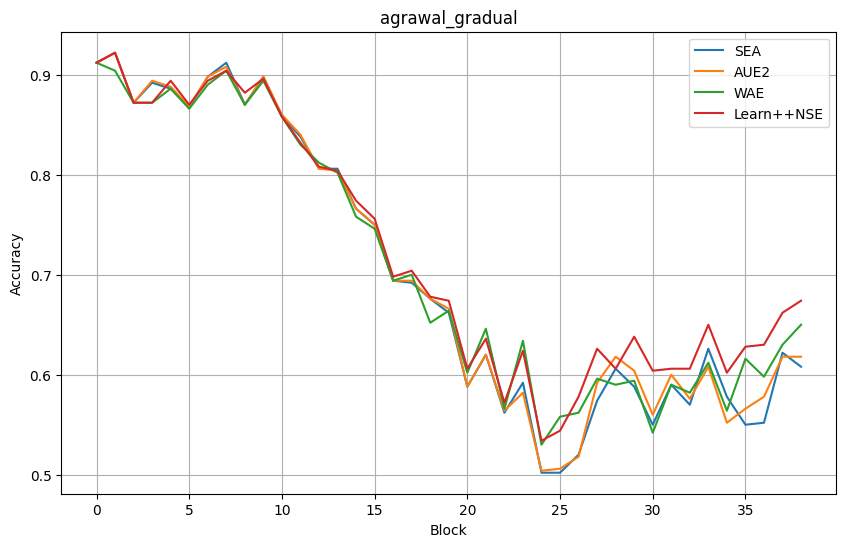

In [6]:
from IPython.display import Image, display
display(Image(filename="plots/agrawal_gradual.png"))

In [7]:
print("=== Recurrent Drift ===")
df_recurrent.style.background_gradient(cmap="Greens")

=== Recurrent Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.739000,0.472000,0.455800,0.259400,13.251000,9.000000,2.000000
2,WAE,0.721500,0.470000,0.415700,0.243000,21.233800,9.000000,2.000000
1,AUE2,0.716100,0.474000,0.408400,0.238700,19.662200,8.500000,2.000000
0,SEA,0.706100,0.474000,0.395100,0.238400,15.639500,8.500000,2.000000


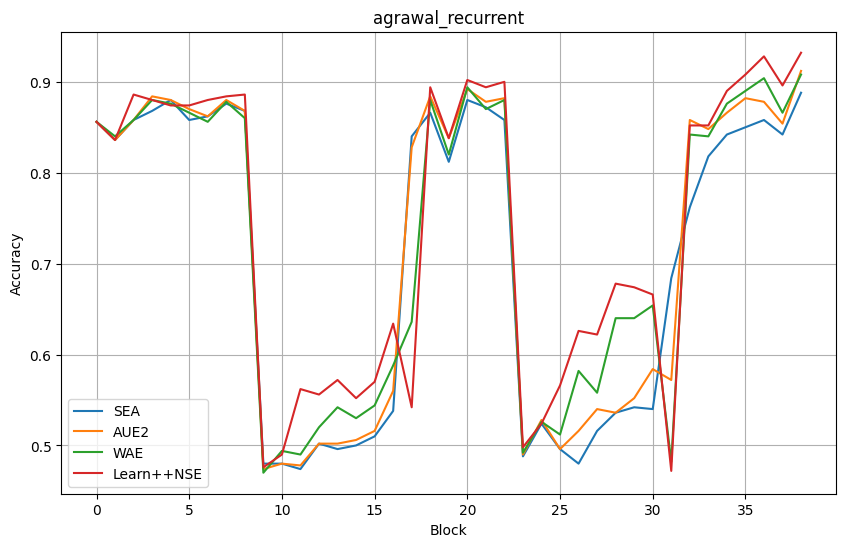

In [8]:

display(Image(filename="plots/agrawal_recurrent.png"))

In [9]:
print("=== Abrupt Drift ===")
df_abrupt.style.background_gradient(cmap="Blues")

=== Abrupt Drift ===


,Model,Accuracy,Min Accuracy,Kappa,Diversity,Time (s),Recovery,Num Drops
3,Learn++NSE,0.722300,0.474000,0.565200,0.209300,13.042800,25.000000,1.000000
2,WAE,0.703900,0.474000,0.536500,0.216600,21.298200,25.000000,1.000000
1,AUE2,0.695800,0.480000,0.532000,0.206600,19.744800,25.000000,1.000000
0,SEA,0.686300,0.476000,0.522500,0.206000,15.927300,25.000000,1.000000


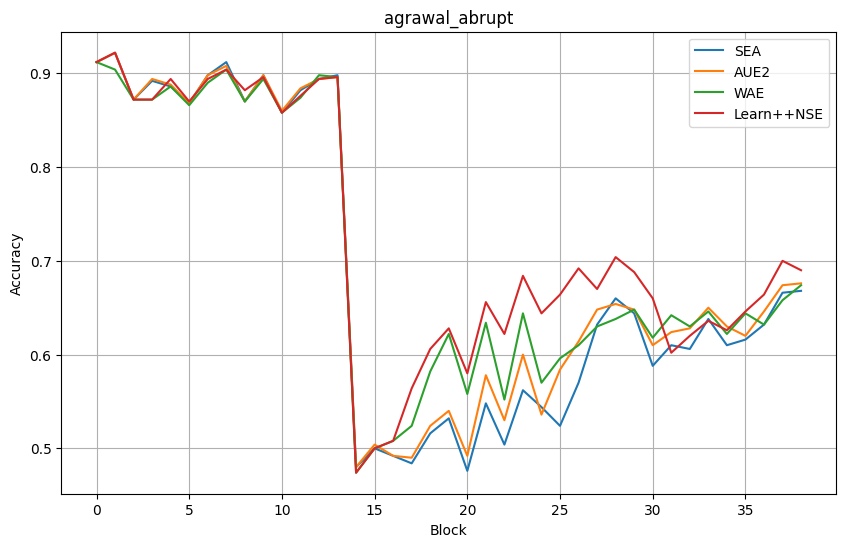

In [10]:

display(Image(filename="plots/agrawal_abrupt.png"))

In [12]:
%pip install pymoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 39.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pymoo]32m6/7 [pymoo]e]
Note: you may need to restart the kernel to use updated packages.


In [3]:

from src.optimization.dynamic_config import DynamicMOEAConfig
from src.optimization.dynamic_runner import run_dynamic_moea_experiment
config3 =DynamicMOEAConfig(
    dataset_path="datasets/agrawal_abrupt.csv",
    window_size=5,
    pop_size=80,
    n_gen=50,
    max_size=20,
    baseline_max_size=20,
    n_jobs=20,
    verbose=True,
    a_min = 0.1,
    a_max = 1.5,
    b_min = 1.0,
    b_max = 8.0,
    grace_period_min = 50,
    grace_period_max = 150,
    log_delta_min = -7,
    log_delta_max = -1,
    recency_lambda_min = 0.5,
    recency_lambda_max = 1.5,
    weight_power_min = 0.8,
    weight_power_max = 1.5,
)

results3 = run_dynamic_moea_experiment(config3)

Dataset: datasets/agrawal_abrupt.csv
Bloques: 40
Cromosoma MOEA: a, b, grace_period, delta, recency_lambda, weigght_power
NSGA-II: pop_size=80, n_gen=50
Objetivos MOEA: maximizar recent_accuracy y diversity; minimizar tiempo de ejecución
Reoptimización pasiva tras bloque 4: a=0.2994, b=7.2733, grace_period=63, delta=4.30e-03, lambda=1.3719, weight_power=1.1689, recent_accuracy=0.9975, diversity=0.1633, elapsed=0.267822s
Reoptimización pasiva tras bloque 5: a=1.4349, b=5.0083, grace_period=99, delta=2.03e-05, lambda=1.4829, weight_power=1.0324, recent_accuracy=0.8684, diversity=0.5372, elapsed=0.272350s
Reoptimización pasiva tras bloque 6: a=0.1186, b=4.2261, grace_period=86, delta=7.56e-02, lambda=1.3747, weight_power=1.1726, recent_accuracy=0.9641, diversity=0.2566, elapsed=0.258880s
Reoptimización pasiva tras bloque 7: a=0.6247, b=7.0620, grace_period=86, delta=4.52e-02, lambda=1.4542, weight_power=1.4849, recent_accuracy=0.9688, diversity=0.2402, elapsed=0.259126s
Reoptimización pas

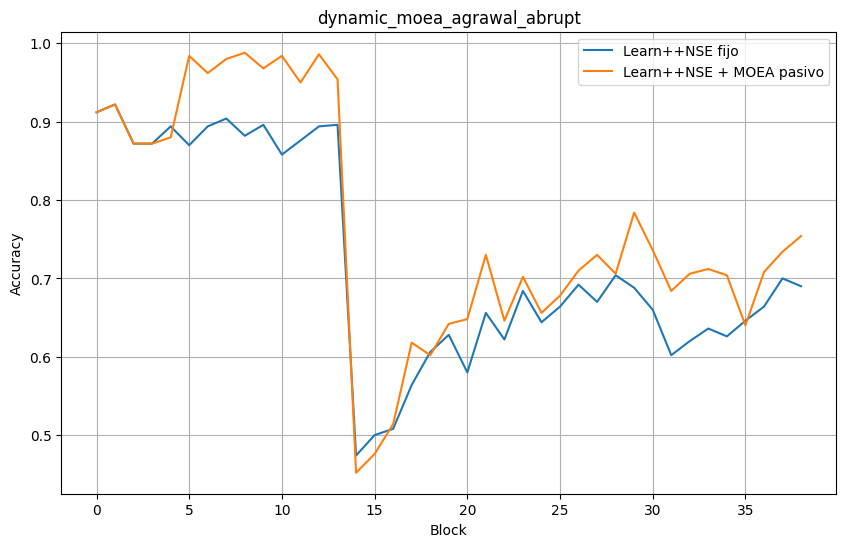

In [4]:
from IPython.display import Image, display
display(Image(filename="plots/dynamic_moea_agrawal_abrupt.png"))

In [5]:
from src.optimization.dynamic_config import DynamicMOEAConfig
from src.optimization.dynamic_runner import run_dynamic_moea_experiment
config4 =DynamicMOEAConfig(
    dataset_path="datasets/agrawal_gradual.csv",
    window_size=5,
    pop_size=80,
    n_gen=50,
    max_size=20,
    baseline_max_size=20,
    n_jobs=20,
    verbose=True,
    a_min = 0.1,
    a_max = 1.5,
    b_min = 1.0,
    b_max = 8.0,
    grace_period_min = 50,
    grace_period_max = 150,
    log_delta_min = -7,
    log_delta_max = -1,
    recency_lambda_min = 0.5,
    recency_lambda_max = 1.5,
    weight_power_min = 0.8,
    weight_power_max = 1.5,
)

results4 = run_dynamic_moea_experiment(config4)

Dataset: datasets/agrawal_gradual.csv
Bloques: 40
Cromosoma MOEA: a, b, grace_period, delta, recency_lambda, weigght_power
NSGA-II: pop_size=80, n_gen=50
Objetivos MOEA: maximizar recent_accuracy y diversity; minimizar tiempo de ejecución
Reoptimización pasiva tras bloque 4: a=1.4509, b=2.2624, grace_period=63, delta=4.67e-03, lambda=1.4342, weight_power=1.1155, recent_accuracy=0.9977, diversity=0.1657, elapsed=0.262178s
Reoptimización pasiva tras bloque 5: a=0.7398, b=4.0406, grace_period=67, delta=1.56e-04, lambda=1.4252, weight_power=0.9744, recent_accuracy=0.9748, diversity=0.2472, elapsed=0.248503s
Reoptimización pasiva tras bloque 6: a=0.4757, b=2.8751, grace_period=86, delta=5.52e-02, lambda=1.4996, weight_power=0.8298, recent_accuracy=0.9681, diversity=0.2560, elapsed=0.253055s
Reoptimización pasiva tras bloque 7: a=0.7498, b=7.9366, grace_period=147, delta=5.15e-02, lambda=1.4863, weight_power=0.8943, recent_accuracy=0.9549, diversity=0.2297, elapsed=0.254637s
Reoptimización p

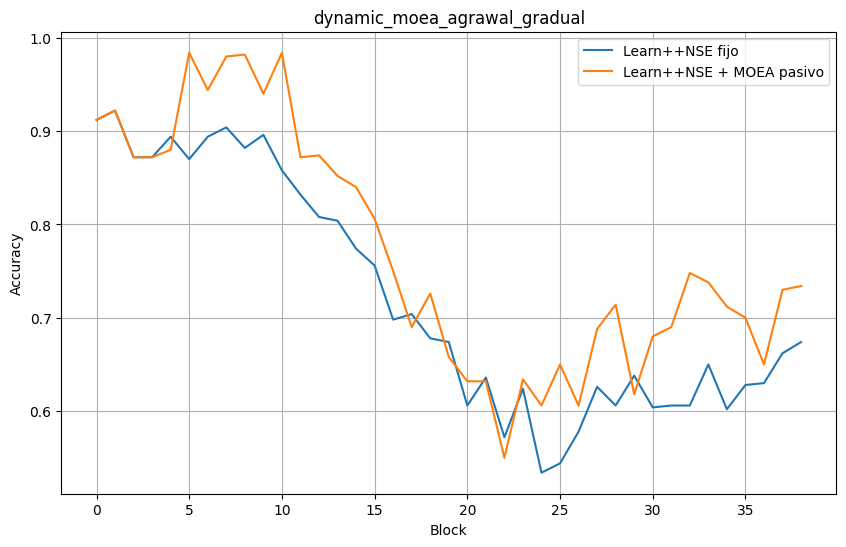

In [6]:
from IPython.display import Image, display
display(Image(filename="plots/dynamic_moea_agrawal_gradual.png"))

In [9]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

pareto = pd.read_csv("results/dynamic_moea_agrawal_abrupt_pareto_history.csv")
pareto.head()

,block_index,a,b,grace_period,delta,recency_lambda,weight_power,recent_accuracy,diversity,complexity,evaluation_elapsed
0,4,1.1684,1.2948,73,0.019921,0.5239,0.8558,1.000000,0.013901,0.288551,0.288551
1,4,1.1684,1.1883,73,0.019921,0.5009,0.8631,1.000000,0.013700,0.286179,0.286179
2,4,0.2864,5.6921,72,0.036644,1.4915,0.9805,0.999070,0.008166,0.278076,0.278076
3,4,0.3614,7.0642,71,0.033036,1.4762,1.1444,0.999053,0.008205,0.279311,0.279311
4,4,0.1191,6.2163,63,0.004303,1.4891,1.1727,0.997946,0.167661,0.273160,0.273160


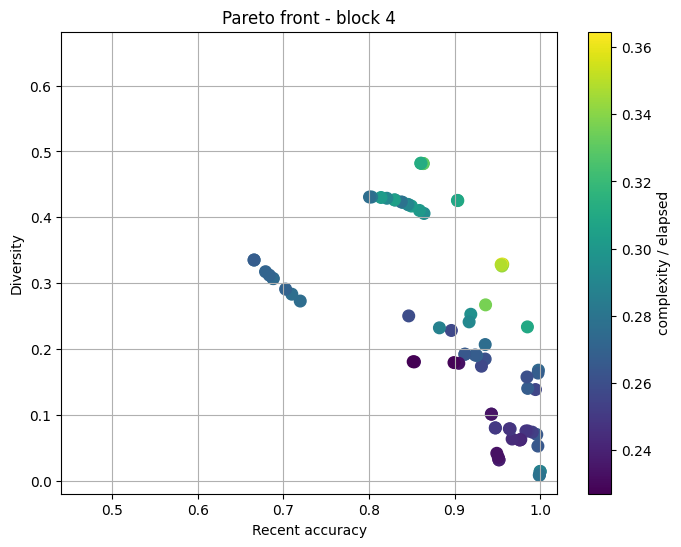

interactive(children=(IntSlider(value=4, description='block', max=38, min=4), Output()), _dom_classes=('widget…

<function __main__.plot_pareto_block(block)>

In [3]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

blocks = sorted(pareto["block_index"].unique())

def plot_pareto_block(block):
    df_b = pareto[pareto["block_index"] == block]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        df_b["recent_accuracy"],
        df_b["diversity"],
        c=df_b["complexity"],
        cmap="viridis",
        s=70,
    )

    plt.colorbar(label="complexity / elapsed")
    plt.xlabel("Recent accuracy")
    plt.ylabel("Diversity")
    plt.title(f"Pareto front - block {block}")
    plt.grid(True)

    # Ejes fijos para comparar visualmente entre bloques
    plt.xlim(pareto["recent_accuracy"].min() - 0.02, pareto["recent_accuracy"].max() + 0.02)
    plt.ylim(pareto["diversity"].min() - 0.02, pareto["diversity"].max() + 0.02)

    plt.show()

interact(
    plot_pareto_block,
    block=IntSlider(
        min=min(blocks),
        max=max(blocks),
        step=1,
        value=blocks[0],
    )
)

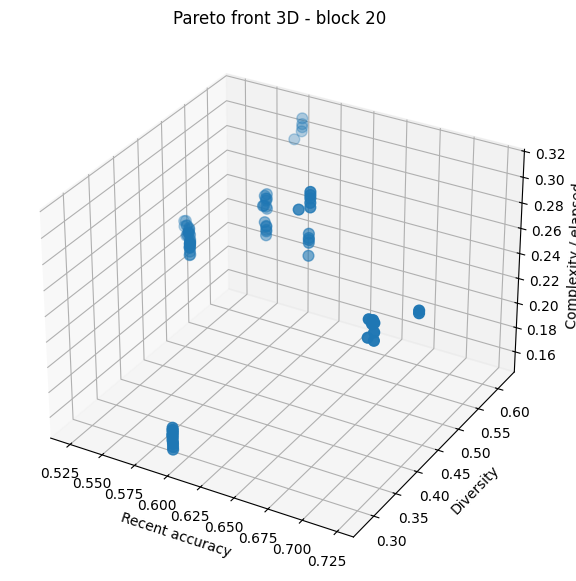

In [4]:
import matplotlib.pyplot as plt

block = 20
df_b = pareto[pareto["block_index"] == block]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_b["recent_accuracy"],
    df_b["diversity"],
    df_b["complexity"],
    s=60,
)

ax.set_xlabel("Recent accuracy")
ax.set_ylabel("Diversity")
ax.set_zlabel("Complexity / elapsed")
ax.set_title(f"Pareto front 3D - block {block}")

plt.show()

<Axes: title={'center': 'Pareto front objective spread per block'}, xlabel='block_index'>

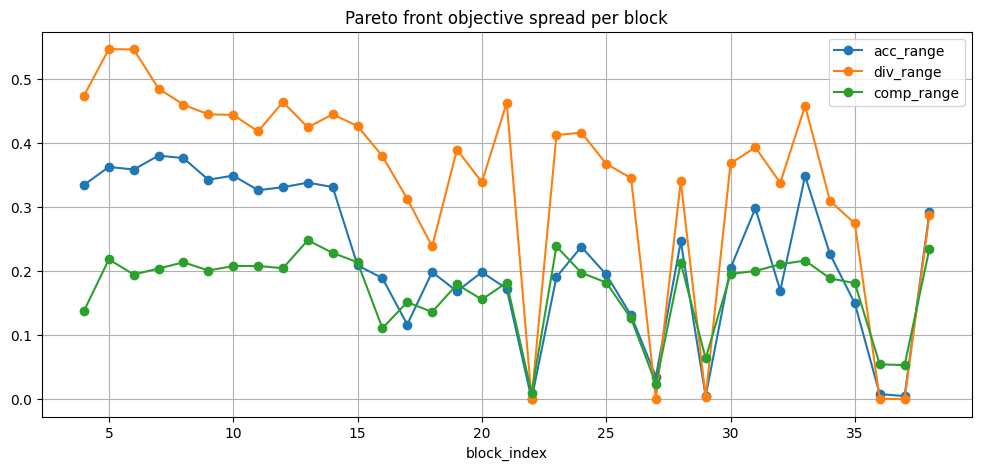

In [5]:
spread = (
    pareto
    .groupby("block_index")
    .agg(
        acc_min=("recent_accuracy", "min"),
        acc_max=("recent_accuracy", "max"),
        div_min=("diversity", "min"),
        div_max=("diversity", "max"),
        comp_min=("complexity", "min"),
        comp_max=("complexity", "max"),
    )
)

spread["acc_range"] = spread["acc_max"] - spread["acc_min"]
spread["div_range"] = spread["div_max"] - spread["div_min"]
spread["comp_range"] = spread["comp_max"] - spread["comp_min"]

spread[["acc_range", "div_range", "comp_range"]].plot(
    figsize=(12, 5),
    marker="o",
    grid=True,
    title="Pareto front objective spread per block",
)